# **Generazione e riconoscimento di tonalità DTMF**

### **Import delle librerie**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft
import os
from src.DTMF_implementation import (
    plot_all_tones_grid,
    dialNumber,
    plot_and_save_sequence,
    plot_spectrum,
    recNumber,
    recSequence,
    dialNumber_pauses,
    detect_sequence_pauses,
    save_plot
)
from src.experiments.duration import run_duration_experiments
from src.experiments.noise import run_noise_experiments
from src.experiments.sampling import run_sampling_experiments
from src.improvements.denoising import run_denoising_experiments
from src.improvements.zero_padding import run_zeropadding_experiments

### **Configurazione struttura cartelle di salvataggio figure + file .wav**

In [2]:
PLOTS_BASE = "Plots"

# Sottocartelle principali
PLOTS_IMPLEMENTATION = os.path.join(PLOTS_BASE, "DTMF_implementation")
PLOTS_EXPERIMENTS = os.path.join(PLOTS_BASE, "experiments")
PLOTS_IMPROVEMENTS = os.path.join(PLOTS_BASE, "improvements")

# Sottocartelle esperimenti
PLOTS_NOISE = os.path.join(PLOTS_EXPERIMENTS, "noise")
PLOTS_DURATION = os.path.join(PLOTS_EXPERIMENTS, "duration")
PLOTS_SAMPLING = os.path.join(PLOTS_EXPERIMENTS, "sampling")

# Sottocartelle miglioramenti
PLOTS_DENOISING = os.path.join(PLOTS_IMPROVEMENTS, "denoising")
PLOTS_ZEROPADDING = os.path.join(PLOTS_IMPROVEMENTS, "zero_padding")

# Cartelle per file audio WAV
AUDIO_BASE = "Audio"
AUDIO_TONES = os.path.join(AUDIO_BASE, "tones")
AUDIO_SEQUENCES = os.path.join(AUDIO_BASE, "sequences")

# Creazione di tutte le cartelle
folders = [
    PLOTS_BASE,
    PLOTS_IMPLEMENTATION,
    PLOTS_EXPERIMENTS,
    PLOTS_IMPROVEMENTS,
    PLOTS_NOISE,
    PLOTS_DURATION,
    PLOTS_SAMPLING,
    PLOTS_DENOISING,
    PLOTS_ZEROPADDING,
    AUDIO_BASE,
    AUDIO_TONES,
    AUDIO_SEQUENCES
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

## **1. Implementazione DTMF**

### **1.1 Creazione del dizionario**

In [3]:
# Definizione delle frequenze DTMF (Standard ETSI)
F1 = np.array([697, 770, 852, 941])      # Frequenze basse (righe)
F2 = np.array([1209, 1336, 1477, 1633])  # Frequenze alte (colonne)

# Definizione del dizionario dei toni
tones = {
    '1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3),
    '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3),
    '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3),
    '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)
}

# Visualizzazione del dizionario
print("Dizionario toni DTMF:")
print(tones)

# Visualizzazione matrice frequenze
print("\nMatrice frequenze DTMF:")
print(f"{'':>5} | {F2[0]:>6} Hz | {F2[1]:>6} Hz | {F2[2]:>6} Hz | {F2[3]:>6} Hz")
print("-" * 60)
for i, f1 in enumerate(F1):
    row = [key for key, (r, c) in tones.items() if r == i]
    print(f"{f1:>3} Hz | {row[0]:>8} | {row[1]:>8} | {row[2]:>8} | {row[3]:>8}")

Dizionario toni DTMF:
{'1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3), '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3), '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3), '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)}

Matrice frequenze DTMF:
      |   1209 Hz |   1336 Hz |   1477 Hz |   1633 Hz
------------------------------------------------------------
697 Hz |        1 |        2 |        3 |        A
770 Hz |        4 |        5 |        6 |        B
852 Hz |        7 |        8 |        9 |        C
941 Hz |        * |        0 |        # |        D


### **1.2 Esempio applicativo**

**Plot dei toni nel dominio del tempo**

In [ ]:
plot_all_tones_grid(duration=0.15, Fs=8000, save_folder=PLOTS_IMPLEMENTATION)

Plot salvato in: Plots/sequenza.png


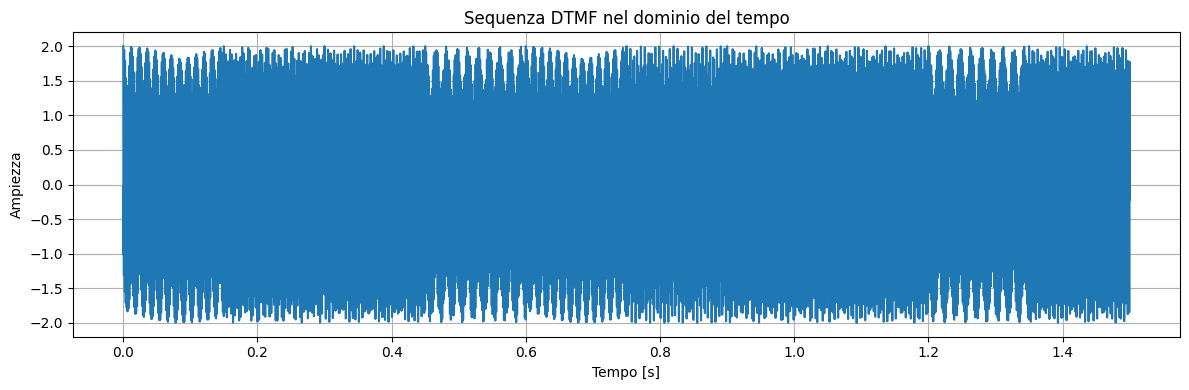

Audio salvato: sequenza.wav
Plot salvato in: Plots/spettro_sequenza.png


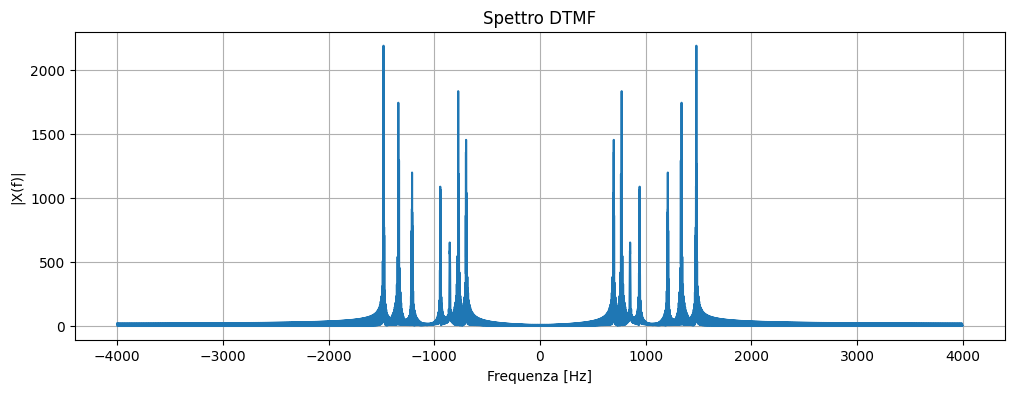

(array([-4000.        , -3999.33333333, -3998.66666667, ...,
         3998.        ,  3998.66666667,  3999.33333333]),
 array([17.50205654-0.j        , -0.43774436-1.24140538j,
         0.0816677 +0.15751167j, ..., -0.41925794-0.93530485j,
         0.0816677 -0.15751167j, -0.43774436+1.24140538j]))

In [14]:
# Generazione e visualizzazione della sequenza '3456318060'
sequenza = "3456318060"
toneDuration = 0.15
full_signal = dialNumber(sequenza, Fs, toneDuration)

plot_and_save_sequence(full_signal, Fs, filename="sequenza.wav", plot_filename="sequenza.png")
# Spettro sequenza
plot_spectrum(full_signal, Fs, plot_filename="spettro_sequenza.png")

In [ ]:
# Riconoscimento della sequenza
detected = recSequence(full_signal, toneDuration=0.15, Fs=8000)
print("Sequenza riconosciuta:", detected)

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


**Inserimento di pause tra un tono e l'altro**

Plot salvato in: Plots/sequenza_pause.png


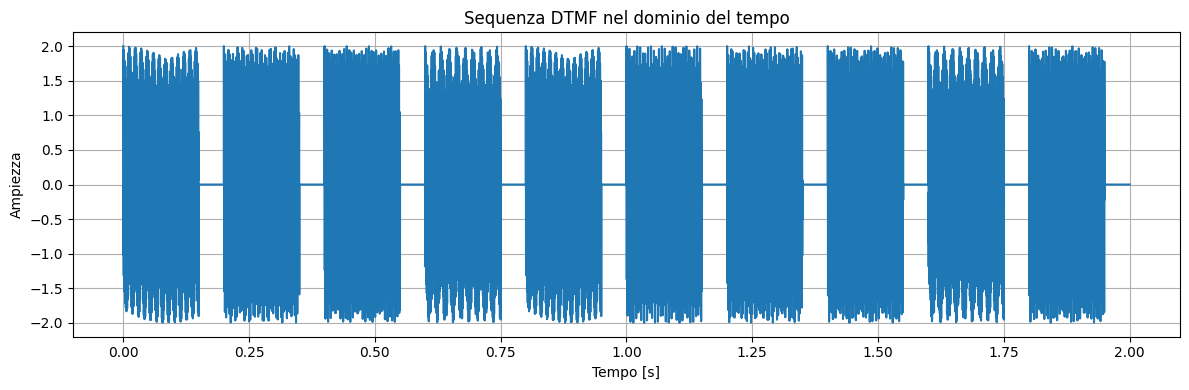

Audio salvato: sequenza_pause.wav
Plot salvato in: Plots/spettro_sequenza_pause.png


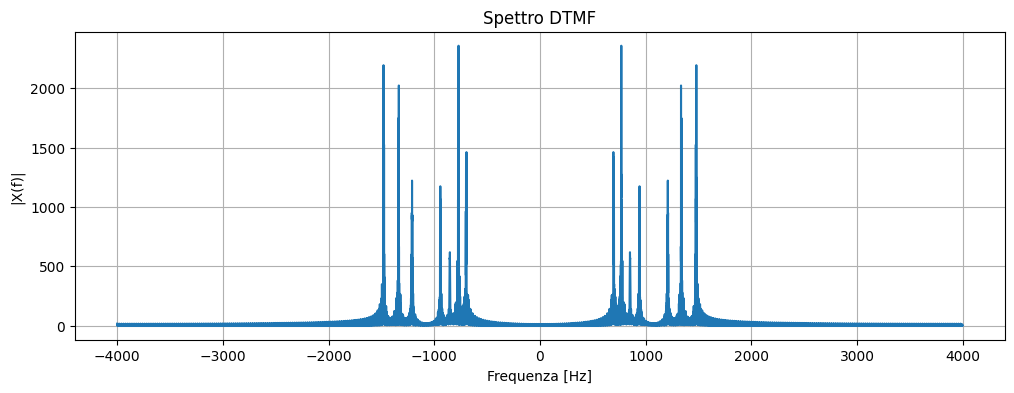

Sequenza riconosciuta: ['3', '4', '5', '6', '3', '1', '8', '0', '6', '0']


In [18]:
full_signal_pauses = dialNumber_pauses(sequenza, Fs, toneDuration, pauseDuration=0.05)

plot_and_save_sequence(full_signal_pauses, Fs, filename="sequenza_pause.wav",
                       plot_filename="sequenza_pause.png")

plot_spectrum(full_signal_pauses, Fs, plot_filename="spettro_sequenza_pause.png")

detected_pauses = detect_sequence_pauses(full_signal_pauses, toneDuration=toneDuration,
                                         pauseDuration=0.05, Fs=Fs, silence_threshold=0.05)

print("Sequenza riconosciuta:", detected_pauses)


Plot salvato in: Plots/spettro_overlay_pause.png


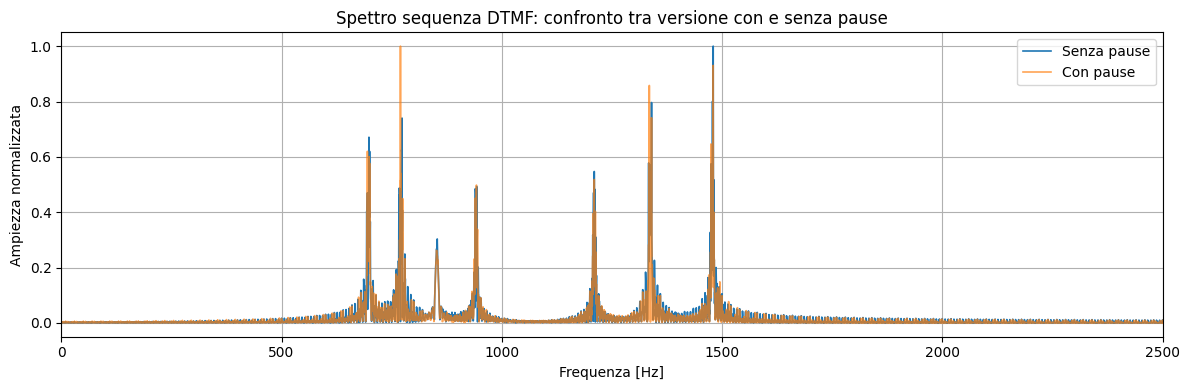

In [19]:
# Lunghezze originali
N_no = len(full_signal)
N_pa = len(full_signal_pauses)

# Lunghezza massima
N = max(N_no, N_pa)

# Padding per allineare le lunghezze
sig_no = np.pad(full_signal, (0, N - N_no), mode='constant')
sig_pa = np.pad(full_signal_pauses, (0, N - N_pa), mode='constant')

# FFT
X_no = fftshift(fft(sig_no))
X_pa = fftshift(fft(sig_pa))

# Ampiezze normalizzate
X_no_norm = np.abs(X_no) / np.max(np.abs(X_no))
X_pa_norm = np.abs(X_pa) / np.max(np.abs(X_pa))

# Asse delle frequenze
freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

# Plot overlay
plt.figure(figsize=(12,4))
plt.plot(freqs, X_no_norm, label="Senza pause", linewidth=1.2)
plt.plot(freqs, X_pa_norm, label="Con pause", alpha=0.7, linewidth=1.2)
plt.xlim(0, 2500)
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Ampiezza normalizzata")
plt.title("Spettro sequenza DTMF: confronto tra versione con e senza pause")
plt.grid(True)
plt.legend()
save_plot("spettro_overlay_pause.png")
plt.show()

## **2. Esperimenti e metodologia**

### **2.1 Variazione della durata del tono**

In [ ]:
# Esegui tutti gli esperimenti sulla durata
results = run_duration_experiments(
    durations=[0.02, 0.05, 0.1, 0.15, 0.2, 0.5],
    Fs=8000,
    n_sequences=100,
    save_folder="Plots_duration"
)

### **2.2 Aggiunta di rumore al segnale**

In [ ]:
# Esegui tutti gli esperimenti sul rumore
results = run_noise_experiments(
    sigmas=[0, 0.05, 0.2, 0.5, 1, 2, 3, 4, 5, 6],
    durations=[0.05, 0.1, 0.15, 0.2, 0.5],
    Fs=8000,
    n_sequences=1000,
    save_folder="Plots_noise"
)

### **2.3 Variazione della frequenza di campionamento**

In [ ]:
results = run_sampling_experiments(
    Fs_list=[2000, 3000, 4000, 6000, 8000, 16000],
    duration=0.15,
    n_sequences=100
)

## **3. Miglioramenti dell'algoritmo**

### **3.1 Zero-padding**

In [ ]:
results = run_zeropadding_experiments(
    durations=[0.02, 0.05, 0.1, 0.15, 0.2],
    M_factors=[1, 2, 4, 8],
    Fs=8000,
    n_sequences=100
)

### **3.2 Filtraggio segnale rumoroso**

In [ ]:
results = run_denoising_experiments(
    sigmas=[0, 0.5, 1, 2, 3, 4],
    Fs=8000,
    n_sequences=1000
)